# Flujo de potencia en AC (Metodo de Newton-Raphson)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandapower as pp
import pandapower.networks as pn
import networkx as nx
from IPython.display import display, Markdown

## Redes de trabajo (Pandapower)

[Case 118](https://pandapower.readthedocs.io/en/v2.13.1/networks/power_system_test_cases.html#case-118)

[Case 145](https://pandapower.readthedocs.io/en/v2.13.1/networks/power_system_test_cases.html#case-145)

[Case 300](https://pandapower.readthedocs.io/en/v2.13.1/networks/power_system_test_cases.html#case-300)

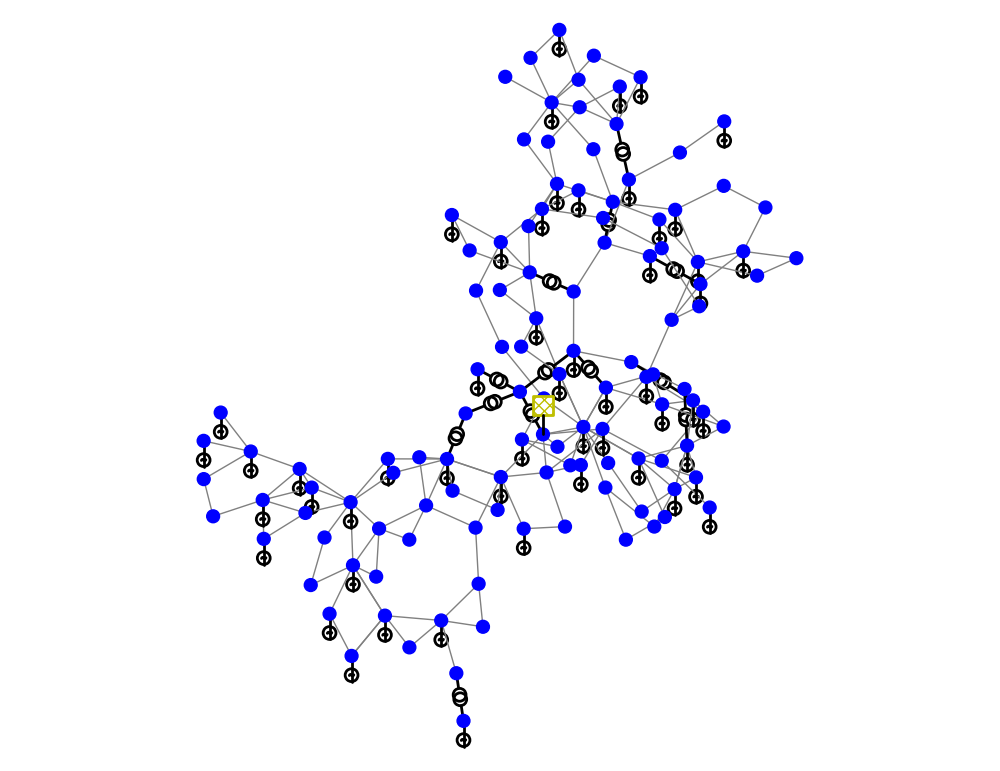

<Axes: >

In [4]:
# Cargar una red de pandapower
net = pn.case118()

# Se puede visualizar el sistema:
import pandapower.plotting as plot
plot.simple_plot(net, plot_gens=True)

In [5]:
# Identificar el bus slack
slack = net.ext_grid['bus'][0]
print(f"El bus slack es: {slack}")

El bus slack es: 68


## Datos y Matriz Ybus desde Pandapower

Para acceder a la matriz $Y_{bus}$ hay que seguir el siguiente procedimiento:

1. Ejecutar un flujo de cargas (`runpp()`),
1. Llamar a la función `_pd2ppc()` para convertir los datos de la red
1. Usar la función `_calc_ybus()` para calcular Ybus.

Esto genera un diccionario con los datos de la red. En la key `internal` del diccionario está la Ybus almacenada como una matriz dispersa de Scipy, para consultar sus valores hay que convertirla a una matriz densa usando la función `todense()`.

Se programan dos funciones:

- `solve_PF_PP` para obtener los resultados del flujo de cargas
- ``get_PFdata_PP`` para obtener la Ybus y Sbase de Pandapower

In [6]:
def solve_PF_PP(net):
    """
    Obtiene los resultados de flujo de potencia de pandapower y los devuelve como un dataframe
    """
    pp.runpp(net)

    bus = net.res_bus
    line = net.res_line
    trafo = net.res_trafo
    load = net.res_load
    gen = net.res_gen

    # Convertir a dataframe
    df_bus = pd.DataFrame(bus)
    df_line = pd.DataFrame(line)
    df_trafo = pd.DataFrame(trafo)
    df_load = pd.DataFrame(load)
    df_gen = pd.DataFrame(gen)

    return df_bus, df_line, df_trafo, df_load, df_gen

def get_PFdata_PP(net):
    '''
    Obtiene parámetros del sistema net: Ybus y Sbase
    '''
    from pandapower.pd2ppc import _pd2ppc
    from pandapower.shortcircuit.impedance import _calc_ybus, _calc_zbus

    pp.runpp(net)
    ppc, ppci = _pd2ppc(net)
    _calc_ybus(ppci)
    Ybus = ppci['internal']['Ybus'].todense()
    Sbase = ppci['baseMVA']
    return Ybus, Sbase

## Almacenar datos en un grafo de Networkx

La función pandapower_to_networkx() exporta los datos del sistema net y genera un grafo con los datos del sistema almacenados en nudos (nodes) y ramas (edges). Se leen los datos de impedancia de ramas y se incorporan sus admitancias como propiedad de los edges.

In [7]:
def pandapower_to_networkx(net, Sbase):
    """
    Convierte una red de pandapower a un grafo de NetworkX.

    Args:
        net (pandapowerNet): La red de pandapower.
        Sbase (float): La base de potencia de la red.

    Returns:
        networkx.Graph: El grafo de NetworkX incluyendo las admitancias de las ramas.
    """

    # Crear un grafo dirigido
    graph = nx.DiGraph()

    # Agregar nodos (buses) al grafo
    for bus_id, bus_data in net.bus.iterrows():
        graph.add_node(bus_id, **bus_data.to_dict())

    # Agregar cargas al grafo
    for load_id, load_data in net.load.iterrows():
        bus = load_data['bus']
        graph.nodes[bus]['load'] = load_data.to_dict()

    # Agregar elementos shunt al grafo
    for shunt_id, shunt_data in net.shunt.iterrows():
        bus = shunt_data['bus']
        graph.nodes[bus]['shunt'] = shunt_data.to_dict()

    # Agregar generadores al grafo
    for gen_id, gen_data in net.gen.iterrows():
        bus = gen_data['bus']
        graph.nodes[bus]['gen'] = gen_data.to_dict()

    # Agregar generadores estáticos al grafo
    for sgen_id, sgen_data in net.sgen.iterrows():
        bus = sgen_data['bus']
        graph.nodes[bus]['sgen'] = sgen_data.to_dict()

    # Agregar redes externas al grafo
    for ext_grid_id, ext_grid_data in net.ext_grid.iterrows():
        bus = ext_grid_data['bus']
        graph.nodes[bus]['ext_grid'] = ext_grid_data.to_dict()

    # Agregar líneas al grafo
    for line_id, line_data in net.line.iterrows():
        from_bus = line_data['from_bus']
        to_bus = line_data['to_bus']
        graph.add_edge(from_bus, to_bus, **line_data.to_dict())
    
    # Agregar transformadores al grafo
    for trafo_id, trafo_data in net.trafo.iterrows():
        hv_bus = trafo_data['hv_bus']
        lv_bus = trafo_data['lv_bus']
        graph.add_edge(hv_bus, lv_bus, **trafo_data.to_dict())

    # Admitancia serie y shunt de las líneas
    Zlohm = (net.line['r_ohm_per_km'] + 1j * net.line['x_ohm_per_km'])* net.line['length_km'] 
    Xlohm = np.imag(Zlohm)
    Yshunt = net.line['c_nf_per_km'] * 1e-9 * (100*np.pi) * net.line['length_km'] * 1j
    Zbase = np.array(net.bus.loc[net.line['from_bus'], 'vn_kv'])**2 / Sbase
    Ylpu = (Zlohm / Zbase)**(-1)
    Xbpu = (Xlohm / Zbase)
    Yshpu = Yshunt * Zbase

    # Admitancia serie y shunt de los transformadores
    Ztpu = (net.trafo['vkr_percent'] / 100 + 1j * (net.trafo['vk_percent']**2-net.trafo['vkr_percent']**2)**0.5 / 100) / net.trafo['sn_mva'] * Sbase
    Ytpu = 1 / Ztpu
    Xtpu = np.imag(Ztpu)
    Ytshpu = 0 * Xtpu
    
    # Agregar admitancia serie, shunt y Xbranch de las líneas al grafo
    for i, row in net.line.iterrows():
        from_bus = row['from_bus']
        to_bus = row['to_bus']
        graph[from_bus][to_bus]['Ybpu'] = Ylpu[i]  
        graph[from_bus][to_bus]['Yshpu'] = Yshpu[i]
        graph[from_bus][to_bus]['Xbpu'] = Xbpu[i]
    
    # Agregar admitancia serie de los trafos al grafo
    for i, row in net.trafo.iterrows():
        hv_bus = row['hv_bus']
        lv_bus = row['lv_bus']
        graph[hv_bus][lv_bus]['Ybpu'] = Ytpu[i] 
        graph[hv_bus][lv_bus]['Yshpu'] = Ytshpu[i]
        graph[hv_bus][lv_bus]['Xbpu'] = Xtpu[i]

    return graph

In [8]:
# Cargar la red de pandapower
net = pn.case14()
Ybus, Sbase = get_PFdata_PP(net)

graph = pandapower_to_networkx(net, Sbase)

def print_Ybranch(graph):
    """
    Imprime las admitancias de las ramas del grafo.
    """
    Ybranch = {}
    for u, v, data in graph.edges(data=True):
        Ybranch[(u, v)] = data['Ybpu']
    
    # Convertir a DataFrame para una mejor visualización
    df_Ybranch = pd.DataFrame.from_dict(Ybranch, orient='index', columns=['Ybpu'])
    display(Markdown("### Admitancias de las ramas (Ybpu)"))
    display(df_Ybranch)

# Ejemplo de uso   
print_Ybranch(graph)

### Admitancias de las ramas (Ybpu)

,Ybpu
"(0, 1)",4.999132-15.263087j
"(0, 4)",1.025897- 4.234984j
"(1, 2)",1.135019- 4.781863j
"(1, 3)",1.686033- 5.115838j
"(1, 4)",1.701140- 5.193927j
"(2, 3)",1.985976- 5.068817j
"(3, 4)",6.840981-21.578554j
"(3, 6)",0.000000- 4.781943j
"(3, 8)",0.000000- 1.797979j
"(4, 5)",0.000000- 3.967939j


## Matrices A, B, S, T

A: Incidencia nudo rama [NxR]

B: Matriz que relaciona los flujos nodales con los ángulos [NxN]
    $$ B = A \cdot X^{-1} \cdot A^T $$

S: Matriz de sensibilidad entre flujos de rama e inyecciones nodales [Rx(N-1)]
    $$ S = X^{-1} \cdot A^{T}_r \cdot B^{-1}_r $$ 

B no es invertible, por lo que requiere descontar una fila y una columna (slack), y la columna del nudo slack en la matriz $A^T$.

T: Relación entre los flujos por rama y los ángulos nodales [Rx(N-1)]
    $$ T =  X^{-1} \cdot A^T_r $$

In [9]:
# 1. Crear un grafo a partir de la red de pandapower
net = pn.case14()
Sbase = get_PFdata_PP(net)[1]
graph = pandapower_to_networkx(net, Sbase)

# 2. Matriz de incidencia nudo-rama
A = nx.incidence_matrix(graph,oriented = True)

# 3. Matriz de reactancia de las ramas (diagonal) [RxR]
X = np.diag([graph.edges[k]['Xbpu'] for k in graph.edges])

# 4. Matriz B (A x X^-1 x A^T) [NxN]
B = A @ np.linalg.inv(X) @ A.T
print('Matriz B:', B[0:3,0:3])

# 5. Matriz S
S = np.linalg.inv(X) @ A.T[:,1:] @ np.linalg.inv(B[1:,1:])
print('Matriz S:', S[0:3,0:3])

# 6. Matrix T
T = np.linalg.inv(X) @ A.T[:,1:]

Matriz B: [[ 21.38395703 -16.90045631   0.        ]
 [-16.90045631  33.37432577  -5.05127039]
 [  0.          -5.05127039  10.89819783]]
Matriz S: [[ 0.8380263   0.74654105  0.66750522]
 [ 0.1619737   0.25345895  0.33249478]
 [-0.02734345  0.53203265  0.15136938]]


## Generar los parámetros de la red desde el Grafo

In [10]:
# 1. Obtener el número de nodos y ramas
num_nodes = graph.number_of_nodes()
num_edges = graph.number_of_edges()

# 2. Crear un vector de cargas (L) inicializado a 0
L = np.zeros(num_nodes)

# 3. Rellenar el vector L con los valores 'p_mw' de la propiedad 'load'
for node_id, node_data in graph.nodes(data=True):
    if 'load' in node_data:
        L[node_id-1] = node_data['load']['p_mw']

# 4. Crear un vector de generación (Gen) inicializado a 0
Gen = np.zeros(num_nodes)
GenMax = np.zeros(num_nodes)
GenMin = np.zeros(num_nodes)

# 5. Rellenar el vector Gen con los valores 'p_mw' de la propiedad 'load'
for node_id, node_data in graph.nodes(data=True):
    if 'gen' in node_data:
        Gen[node_id-1] = node_data['gen']['p_mw']
        GenMax[node_id-1] = node_data['gen']['max_p_mw']
        GenMin[node_id-1] = node_data['gen']['min_p_mw']
    
# 6. Pasar los valores a pu
L = L/Sbase
Gen = Gen/Sbase
GenMax = GenMax/Sbase
GenMin = GenMin/Sbase

# 7. Obtener los datos de flujo máximo de las ramas
SmaxBranch = np.zeros(num_edges)
for i, (u, v, data) in enumerate(graph.edges(data=True)):
    if 'max_i_ka' in data:
        vn = graph.nodes[u]['vn_kv']
        SmaxBranch[i] = data['max_i_ka'] * np.sqrt(3) * vn / Sbase
    elif 'sn_mva' in data:
        SmaxBranch[i] = data['sn_mva'] / Sbase
    #else:
    #    SmaxBranch[i] = 1e6 / Sbase
print(SmaxBranch)
print(L)

[99. 99. 99. 99. 99. 99. 99. 99. 99. 99. 99. 99. 99. 99. 99. 99. 99. 99.
 99. 99.]
[0.217 0.942 0.478 0.076 0.112 0.    0.    0.295 0.09  0.035 0.061 0.135
 0.149 0.   ]


# Flujo de potencia en AC

1- Generar la matriz Ybus incluyendo las admitancias shunt de las ramas
    $$ Y_{bus} = A \cdot Y_b \cdot A^T + diag(|A| \cdot Y_{sh}\cdot \frac{1}{2}) $$

- $Y_{sh}$ es un vector [R x 1] que contiene las admitancias shunt
- $Y_{b}$ es una matriz de 0 que contiene las admitancias de rama en la diagonal principal [R x R] 
- $|A|$ es la matriz de incidencia nudo-rama en la que los valores -1 se cambian por +1. 

In [11]:
# 1. Generar la matriz Ybus incluyendo las admitancias shunt de las ramas

Ybranch = np.diag([graph.edges[k]['Ybpu'] for k in graph.edges])

Yshb = [graph.edges[k]['Yshpu'] for k in graph.edges]

Ybus = A @ Ybranch @ A.T + np.diag(np.abs(A) @ Yshb*0.5)

Ybus

array([[ 6.02502906-19.45557021j, -4.9991316 +15.26308652j,
         0.         +0.j        ,  0.         +0.j        ,
        -1.02589745 +4.23498368j,  0.         +0.j        ,
         0.         +0.j        ,  0.         +0.j        ,
         0.         +0.j        ,  0.         +0.j        ,
         0.         +0.j        ,  0.         +0.j        ,
         0.         +0.j        ,  0.         +0.j        ],
       [-4.9991316 +15.26308652j,  9.52132361-30.28588207j,
        -1.13501919 +4.78186315j, -1.68603315 +5.11583833j,
        -1.70113967 +5.1939274j ,  0.         +0.j        ,
         0.         +0.j        ,  0.         +0.j        ,
         0.         +0.j        ,  0.         +0.j        ,
         0.         +0.j        ,  0.         +0.j        ,
         0.         +0.j        ,  0.         +0.j        ],
       [ 0.         +0.j        , -1.13501919 +4.78186315j,
         3.1209949  -9.8270968j , -1.98597571 +5.06881698j,
         0.         +0.j        ,  0. 

## Método de Newton-Raphson para el flujo de potencia en AC


## 1. Introducción
El problema del flujo de potencia (o flujo de cargas) consiste en determinar el estado operativo de un sistema eléctrico de potencia en régimen permanente. El objetivo es calcular las magnitudes y ángulos de los voltajes en todas las barras, así como los flujos de potencia activa ($P$) y reactiva ($Q$) en las líneas de transmisión.

El método de **Newton-Raphson (N-R)** es el más utilizado debido a su convergencia cuadrática y eficiencia en sistemas de gran escala.

## 2. Las Ecuaciones de Flujo de Potencia
Para cada barra $i$ en un sistema de $n$ barras, las potencias neta inyectada se expresan como:

$$P_i = |V_i| \sum_{j=1}^{n} |V_j| (G_{ij} \cos \delta_{ij} + B_{ij} \sin \delta_{ij})$$
$$Q_i = |V_i| \sum_{j=1}^{n} |V_j| (G_{ij} \sin \delta_{ij} - B_{ij} \cos \delta_{ij})$$

Donde:
- $|V_i|, \delta_i$: Magnitud y ángulo del voltaje en la barra $i$.
- $\delta_{ij} = \delta_i - \delta_j$.
- $G_{ij} + jB_{ij}$: Elementos de la matriz de admitancia de bus ($Y_{bus}$).

## 3. Fundamento del Método de Newton-Raphson
El método busca encontrar las raíces de un sistema de ecuaciones mediante una expansión en serie de Taylor, despreciando los términos de orden superior. En el flujo de potencia, definimos los "residuos" o desbalances de potencia ($\Delta P$ y $\Delta Q$):

$$\Delta P_i = P_{i, \text{prog}} - P_{i, \text{calc}}$$
$$\Delta Q_i = Q_{i, \text{prog}} - Q_{i, \text{calc}}$$

La relación linealizada entre los residuos y las correcciones de las variables de estado (ángulos $\Delta \delta$ y magnitudes $\Delta |V|$) se define mediante la **Matriz Jacobiana ($J$):**

$$
\begin{bmatrix} \Delta P \\ \Delta Q \end{bmatrix} = 
\begin{bmatrix} J_{1} & J_{2} \\ J_{3} & J_{4} \end{bmatrix}
\begin{bmatrix} \Delta \delta \\ \Delta |V| \end{bmatrix}
$$

### Submatrices del Jacobiano
- **$J_1$ ($\partial P / \partial \delta$):** Relación entre potencia activa y ángulos.
- **$J_2$ ($\partial P / \partial |V|$):** Relación entre potencia activa y magnitudes de voltaje.
- **$J_3$ ($\partial Q / \partial \delta$):** Relación entre potencia reactiva y ángulos.
- **$J_4$ ($\partial Q / \partial |V|$):** Relación entre potencia reactiva y magnitudes de voltaje.

## 4. Algoritmo de Solución
1.  **Inicialización:** Asignar valores iniciales (usualmente un "flat start": $|V| = 1.0$ p.u. y $\delta = 0^\circ$ para todas las barras, excepto la barra Slack).
2.  **Cálculo de Potencias:** Calcular $P_{i, \text{calc}}$ y $Q_{i, \text{calc}}$ usando los valores actuales de voltaje.
3.  **Cálculo de Residuos:** Determinar $\Delta P$ y $\Delta Q$. Si todos los residuos son menores que una tolerancia predefinida ($\epsilon$), el proceso termina.
4.  **Construcción del Jacobiano:** Evaluar las derivadas parciales con los valores actuales.
5.  **Resolución del Sistema Lineal:** Resolver la ecuación matricial para hallar los incrementos $\Delta \delta$ y $\Delta |V|$.
6.  **Actualización de Variables:** - $\delta_{new} = \delta_{old} + \Delta \delta$
    - $|V|_{new} = |V|_{old} + \Delta |V|$
7.  **Iteración:** Repetir desde el paso 2.

## 5. Ventajas y Limitaciones
### Ventajas
- **Convergencia rápida:** Posee una tasa de convergencia cuadrática (el error se reduce al cuadrado en cada iteración cerca de la solución).
- **Independencia del tamaño:** El número de iteraciones es relativamente independiente del número de barras del sistema.
- **Precisión:** Muy alta para sistemas bien condicionados.

### Limitaciones
- **Sensibilidad al punto inicial:** Si el valor inicial está muy lejos de la solución real, el método puede divergir.
- **Costo computacional por iteración:** Calcular y memorizar el Jacobiano es costoso, aunque se mitiga usando técnicas de matrices dispersas (Sparsity).


In [ ]:
#Buscamos obtener las potencias programadas en cada barra y el tipo de barra (slack, PV, PQ) para cada barra

def get_bus_specs(net, Sbase):
    n = len(net.bus)
    P_prog = np.zeros(n)
    Q_prog = np.zeros(n)
    V_init = np.ones(n)
    delta_init = np.zeros(n)
    bus_types = []  # 0: Slack, 1: PV, 2: PQ

    for i in range(n):
        # 1. Cargas (P y Q consumidas -> Signo negativo)
        # Buscamos si hay cargas conectadas a esta barra i
        p_load = net.load.loc[net.load.bus == i, 'p_mw'].sum() / Sbase
        q_load = net.load.loc[net.load.bus == i, 'q_mvar'].sum() / Sbase
        
        # 2. Generación
        p_gen = net.gen.loc[net.gen.bus == i, 'p_mw'].sum() / Sbase
        
        # 3. Identificar tipo de barra y voltajes iniciales
        # PRIORIDAD 1: Slack (External Grid)
        if i in net.ext_grid.bus.values:
            bus_types.append(0) 
            V_init[i] = net.ext_grid.loc[net.ext_grid.bus == i, 'vm_pu'].values[0]
            delta_init[i] = np.radians(net.ext_grid.loc[net.ext_grid.bus == i, 'va_degree'].values[0])
            P_prog[i] = 0 
            Q_prog[i] = 0
            
        # PRIORIDAD 2: PV (Generadores)
        elif i in net.gen.bus.values:
            bus_types.append(1)
            # En PV el voltaje es un dato, no una variable
            V_init[i] = net.gen.loc[net.gen.bus == i, 'vm_pu'].values[0]
            P_prog[i] = p_gen - p_load
            Q_prog[i] = 0 
            
        # PRIORIDAD 3: PQ (Cargas o barras de paso)
        else:
            bus_types.append(2)
            P_prog[i] = - p_load
            Q_prog[i] = - q_load

    return V_init, delta_init, P_prog, Q_prog, bus_types

In [ ]:
#Implementeamos ahora el codigo de Newton Raphson, tomando los valores de la Ybus que se calcularon previamente extraidos con Pandapower

def solve_newton_raphson(Ybus, V_init, d_init, P_prog, Q_prog, bus_types, tol=1e-8, max_it=10):
    V = np.copy(V_init)
    delta = np.copy(d_init)
    n = len(V)
    
    # Índices para el Jacobiano
    pv = [i for i, t in enumerate(bus_types) if t == 1]
    pq = [i for i, t in enumerate(bus_types) if t == 2]
    non_slack = pv + pq
    
    G = Ybus.real
    B = Ybus.imag

    for it in range(max_it):
        # --- Cálculo de P y Q calculadas ---
        P_calc = np.zeros(n)
        Q_calc = np.zeros(n)
        for i in range(n):
            for j in range(n):
                d_ij = delta[i] - delta[j]
                P_calc[i] += V[i]*V[j]*(G[i,j]*np.cos(d_ij) + B[i,j]*np.sin(d_ij))
                Q_calc[i] += V[i]*V[j]*(G[i,j]*np.sin(d_ij) - B[i,j]*np.cos(d_ij))
        
        # --- Residuos ---
        dP = P_prog[non_slack] - P_calc[non_slack]
        dQ = Q_prog[pq] - Q_calc[pq]
        mismatch = np.concatenate([dP, dQ])
        
        if np.max(np.abs(mismatch)) < tol:
            print(f"Convergió en {it} iteraciones.")
            break

        # --- Construcción del Jacobiano 
        # Dimensiones: (n_non_slack + n_pq) x (n_non_slack + n_pq)
        n_ns = len(non_slack)
        n_pq = len(pq)
        J1 = np.zeros((n_ns, n_ns))
        J2 = np.zeros((n_ns, n_pq))
        J3 = np.zeros((n_pq, n_ns))
        J4 = np.zeros((n_pq, n_pq))
        
# Llenado de J1 y J2 (Derivadas de P)
        for idx_i, i in enumerate(non_slack):
            for idx_j, j in enumerate(non_slack):
                d_ij = delta[i] - delta[j]
                if i != j:
                    # J1: dP/ddelta (Fuera diagonal)
                    J1[idx_i, idx_j] = V[i]*V[j]*(G[i,j]*np.sin(d_ij) - B[i,j]*np.cos(d_ij))
                    # J2: dP/dV (Fuera diagonal - solo si j es PQ)
                    if j in pq:
                        idx_vj = pq.index(j)
                        J2[idx_i, idx_vj] = V[i]*(G[i,j]*np.cos(d_ij) + B[i,j]*np.sin(d_ij))
                else:
                    # J1: Diagonal
                    J1[idx_i, idx_j] = -Q_calc[i] - (V[i]**2)*B[i,i]
                    # J2: Diagonal (solo si i es PQ)
                    if i in pq:
                        idx_vi = pq.index(i)
                        J2[idx_i, idx_vi] = (P_calc[i]/V[i]) + G[i,i]*V[i]

    # Llenado de J3 y J4 (Derivadas de Q)
        for idx_i, i in enumerate(pq):
            for idx_j, j in enumerate(non_slack):
                d_ij = delta[i] - delta[j]
                if i != j:
                    # J3: dQ/ddelta (Fuera diagonal)
                    J3[idx_i, idx_j] = -V[i]*V[j]*(G[i,j]*np.cos(d_ij) + B[i,j]*np.sin(d_ij))
                    
                    # J4: dQ/dV (Fuera diagonal - solo si j es barra tipo PQ)
                    if j in pq:
                        idx_vj = pq.index(j)
                        J4[idx_i, idx_vj] = V[i]*(G[i,j]*np.sin(d_ij) - B[i,j]*np.cos(d_ij))
                else:
                    # J3: Diagonal                   
                    J3[idx_i, idx_j] = P_calc[i] - (V[i]**2)*G[i,i]
                    
                    # J4: Diagonal (solo si i es PQ)
                    J4[idx_i, idx_i] = (Q_calc[i]/V[i]) - V[i]*B[i,i]
        
        # Ensamblaje de la matriz J 
        J = np.block([[J1, J2], [J3, J4]])
        
        # --- 5. Resolución del Sistema Lineal ---
        dx = np.linalg.solve(J, mismatch)
        
        # --- 6. Actualización de Variables ---
        delta[non_slack] += dx[:n_ns]
        V[pq] += dx[n_ns:]

        if it == max_it - 1:
            print("Advertencia: No se alcanzó la convergencia máxima.")
        
    return V, np.degrees(delta)

In [19]:
# 1. Cargar la red y obtener parámetros base
net = pn.case14()
Sbase = 100.0  # MVA base típica para estos casos

# 2. Obtener la Ybus 

Ybus, _ = get_PFdata_PP(net) 

# 3. Preparar los datos de entrada para Newton-Raphson
V_init, d_init, P_prog, Q_prog, bus_types = get_bus_specs(net, Sbase)

# 4. Ejecutar el algoritmo de Newton-Raphson
V_final, d_final = solve_newton_raphson(
    Ybus, V_init, d_init, P_prog, Q_prog, bus_types, tol=1e-8, max_it=20
)

# 5. Obtener resultados de Pandapower para comparar
pp.runpp(net, algorithm='nr')
v_pp = net.res_bus.vm_pu.values
d_pp = net.res_bus.va_degree.values

# 6. Crear DataFrame de comparación
comparacion = pd.DataFrame({
    'Bus': net.bus.index,
    'V_calc (pu)': V_final,
    'V_pp (pu)': v_pp,
    'Error_V (%)': np.abs(V_final - v_pp) * 100,
    'Ang_calc (deg)': d_final,
    'Ang_pp (deg)': d_pp,
    'Error_Ang (deg)': np.abs(d_final - d_pp)
})

print("\n--- Resultados del Flujo de Potencia (Newton-Raphson vs Pandapower) ---")
display(comparacion)

Convergió en 4 iteraciones.

--- Resultados del Flujo de Potencia (Newton-Raphson vs Pandapower) ---


,Bus,V_calc (pu),V_pp (pu),Error_V (%),Ang_calc (deg),Ang_pp (deg),Error_Ang (deg)
0,0,1.060000,1.060000,0.000000e+00,0.000000,0.000000,0.000000e+00
1,1,1.045000,1.045000,2.220446e-14,-4.982589,-4.982589,1.518989e-10
2,2,1.010000,1.010000,2.220446e-14,-12.725100,-12.725100,3.434071e-10
3,3,1.017671,1.017671,6.197487e-10,-10.312901,-10.312901,2.566338e-10
4,4,1.019514,1.019514,5.482059e-10,-8.773854,-8.773854,1.807674e-10
5,5,1.070000,1.070000,2.220446e-14,-14.220946,-14.220946,3.832934e-10
6,6,1.061520,1.061520,3.208545e-10,-13.359627,-13.359627,2.911591e-10
7,7,1.090000,1.090000,0.000000e+00,-13.359627,-13.359627,2.911538e-10
8,8,1.055932,1.055932,3.221645e-10,-14.938521,-14.938521,3.252492e-10
9,9,1.050985,1.050985,2.720046e-10,-15.097288,-15.097288,3.418457e-10


In [ ]:
# 1. Cargamos la nueva red
net = pn.case33bw() # 

# 2. Cargamos la Ybus y Sbase usando la función previa
Ybus, Sbase = get_PFdata_PP(net)
V_init, d_init, P_prog, Q_prog, bus_types = get_bus_specs(net, Sbase)

# 3. Ejecutamos El Newton Raphson
V_final, d_final = solve_newton_raphson(Ybus, V_init, d_init, P_prog, Q_prog, bus_types)


# 5. Obtener resultados de Pandapower para comparar
pp.runpp(net, algorithm='nr')
v_pp = net.res_bus.vm_pu.values
d_pp = net.res_bus.va_degree.values

# 6. Crear DataFrame de comparación
comparacion = pd.DataFrame({
    'Bus': net.bus.index,
    'V_calc (pu)': V_final,
    'V_pp (pu)': v_pp,
    'Error_V (%)': np.abs(V_final - v_pp) * 100,
    'Ang_calc (deg)': d_final,
    'Ang_pp (deg)': d_pp,
    'Error_Ang (deg)': np.abs(d_final - d_pp)
})

print("\n--- Resultados del Flujo de Potencia (Newton-Raphson vs Pandapower) ---")
display(comparacion)

Convergió en 3 iteraciones.

--- Resultados del Flujo de Potencia (Newton-Raphson vs Pandapower) ---


,Bus,V_calc (pu),V_pp (pu),Error_V (%),Ang_calc (deg),Ang_pp (deg),Error_Ang (deg)
0,0,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
1,1,0.997032,0.997032,2.492562e-09,0.014481,0.014481,6.300372e-11
2,2,0.982938,0.982938,1.579533e-08,0.096042,0.096042,5.696688e-10
3,3,0.975456,0.975456,2.549974e-08,0.161651,0.161651,1.392562e-09
4,4,0.968059,0.968059,3.538978e-08,0.228285,0.228285,3.021512e-09
5,5,0.949658,0.949658,5.911468e-08,0.133853,0.133853,1.015653e-08
6,6,0.946173,0.946173,5.928992e-08,-0.096474,-0.096474,1.682073e-08
7,7,0.941328,0.941328,6.135098e-08,-0.060403,-0.060403,2.150753e-08
8,8,0.935059,0.935059,6.352493e-08,-0.133484,-0.133485,3.342583e-08
9,9,0.929244,0.929244,6.519897e-08,-0.196014,-0.196014,4.853980e-08
